<a href="https://colab.research.google.com/github/zeeshan3106/Deep-Learning/blob/main/CNN%20Model%20For%20Cats%20Vs%20Dogs%20Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import tensorflow_datasets as tfds

(train_ds, test_ds), info = tfds.load(
    "cats_vs_dogs",
    split=["train[:80%]", "train[80%:]"],
    as_supervised=True,
    with_info=True
)

print(info)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

/usr/local/lib/python3.12/dist-packages/google/protobuf/runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/google/protobuf/runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/google/protobuf/runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/resource_handle.proto. Please update the gencode to avoid compatibility violations in the next r

Shuffling /root/tensorflow_datasets/cats_vs_dogs/incomplete.CFP5GT_4.0.1/cats_vs_dogs-train.tfrecord-[0-9][0-9…

Dataset cats_vs_dogs downloaded and prepared to /root/tensorflow_datasets/cats_vs_dogs/4.0.1. Subsequent calls will reuse this data.
tfds.core.DatasetInfo(
    name='cats_vs_dogs',
    full_name='cats_vs_dogs/4.0.1',
    description="""
    A large set of images of cats and dogs. There are 1738 corrupted images that are dropped.
    """,
    homepage='https://www.microsoft.com/en-us/download/details.aspx?id=54765',
    data_dir='/root/tensorflow_datasets/cats_vs_dogs/4.0.1',
    file_format=tfrecord,
    download_size=786.67 MiB,
    dataset_size=1.04 GiB,
    features=FeaturesDict({
        'image': Image(shape=(None, None, 3), dtype=uint8),
        'image/filename': Text(shape=(), dtype=string),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=2),
    }),
    supervised_keys=('image', 'label'),
    disable_shuffling=False,
    nondeterministic_order=False,
    splits={
        'train': <SplitInfo num_examples=23262, num_shards=16>,
    },
    citation="""@Inproceedings 

In [3]:
# To make the values between 0 and 1

import tensorflow as tf

IMG_SIZE = 256
BATCH_SIZE = 32

def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = image / 255.0
    return image, label

train_ds = train_ds.map(preprocess)
test_ds = test_ds.map(preprocess)

train_ds = train_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [4]:
for images, labels in train_ds.take(1):
    print(images.shape)
    print(labels.shape)

(32, 256, 256, 3)
(32,)


In [5]:
from tensorflow.keras.layers import Dense,Conv2D,MaxPooling2D,Dropout,Flatten
from tensorflow.keras import Sequential

In [6]:
model = Sequential()
model.add(Conv2D(32,kernel_size=(3,3), padding="same",activation="relu",input_shape=(256,256,3)))
MaxPooling2D(pool_size=(2,2), strides=2)

model.add(Flatten())
model.add(Dense(64,activation="relu" ))
model.add(Dense(32,activation="relu" ))
model.add(Dense(16,activation="relu" ))
model.add(Dense(1,activation="sigmoid" ))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 256, 256, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2097152)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │   134,217,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,221,313 (512.01 MB)

 Trainable params: 134,221,313 (512.01 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
model.compile(loss="binary_crossentropy",optimizer="adam",metrics=['accuracy'])
history = model.fit(train_ds,epochs=20, validation_data=test_ds)

Epoch 1/20
582/582 ━━━━━━━━━━━━━━━━━━━━ 58s 79ms/step - accuracy: 0.6302 - loss: 1.1070 - val_accuracy: 0.6844 - val_loss: 0.5966
Epoch 2/20
582/582 ━━━━━━━━━━━━━━━━━━━━ 41s 70ms/step - accuracy: 0.7318 - loss: 0.5302 - val_accuracy: 0.6739 - val_loss: 0.6470
Epoch 3/20
582/582 ━━━━━━━━━━━━━━━━━━━━ 44s 75ms/step - accuracy: 0.8455 - loss: 0.3473 - val_accuracy: 0.6748 - val_loss: 0.8350
Epoch 4/20
582/582 ━━━━━━━━━━━━━━━━━━━━ 46s 78ms/step - accuracy: 0.9111 - loss: 0.2152 - val_accuracy: 0.6541 - val_loss: 1.1149
Epoch 5/20
582/582 ━━━━━━━━━━━━━━━━━━━━ 48s 83ms/step - accuracy: 0.9454 - loss: 0.1459 - val_accuracy: 0.6728 - val_loss: 1.1600
Epoch 6/20
582/582 ━━━━━━━━━━━━━━━━━━━━ 73s 67ms/step - accuracy: 0.9648 - loss: 0.0996 - val_accuracy: 0.6548 - val_loss: 1.3206
Epoch 7/20
582/582 ━━━━━━━━━━━━━━━━━━━━ 37s 64ms/step - accuracy: 0.9762 - loss: 0.0756 - val_accuracy: 0.6599 - val_loss: 1.4378
Epoch 8/20
582/582 ━━━━━━━━━━━━━━━━━━━━ 37s 64ms/step - accuracy: 0.9778 - loss: 0.0697 - 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step


array([[0.]], dtype=float32)

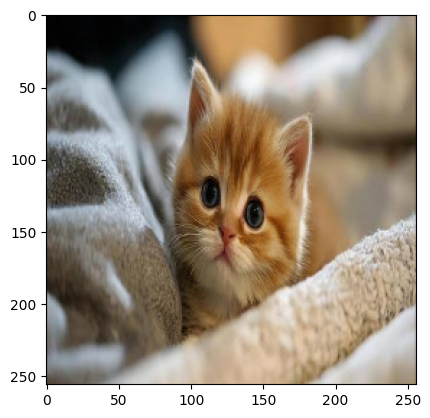

In [40]:
import matplotlib.pyplot as plt
import cv2
test = cv2.imread("images (10).jfif")
test = cv2.cvtColor(test,cv2.COLOR_BGR2RGB)

import numpy as np

test = cv2.resize(test,(256,256))
plt.imshow(test)
test = np.reshape(test,(1,256,256,3))
model.predict(test)
